In [172]:
import optuna
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, MonthLocator, YearLocator
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import datetime
import holidays
import os
import logging
import sys
from prophet.diagnostics import cross_validation
from optuna.logging import set_verbosity
import json
from typing import Any, Dict, List, Tuple, Optional

In [173]:
#file_path_sbp = r'data_sbp_SKB_eacq_x_target_prophet.xlsx'
set_verbosity(optuna.logging.WARNING)
file_path_eacq = r'data_eacq_SKB_fnal.xlsx' 


In [174]:
### выходные ###
today = datetime.date.today()
years = list(range(2022, today.year + 1))
country_holidays = holidays.Russia(years=years)
holidays_df = pd.DataFrame([
    {'ds': pd.to_datetime(dt), 'holiday': name, 'lower_window': 0, 'upper_window': 3}
    for dt, name in country_holidays.items()
])

In [260]:
warnings.filterwarnings("ignore")
file_path_eacq = r'data_eacq_SKB_fnal.xlsx' 
df = pd.read_excel(file_path_eacq)
df.head()

,VALUE_DAY,FEE_RUR_AMT_SUM
0,2023-01-01,1.759940e+08
1,2023-01-02,1.297660e+08
2,2023-01-03,1.655260e+08
3,2023-01-04,1.838775e+08
4,2023-01-05,2.022027e+08


In [261]:
df_prophet_eacq = df.copy()  # замените на реальные имена столбцов
df_prophet_eacq.rename(columns={'VALUE_DAY': 'ds', 'FEE_RUR_AMT_SUM': 'y'}, inplace=True)
df_prophet_eacq.head()

,ds,y
0,2023-01-01,1.759940e+08
1,2023-01-02,1.297660e+08
2,2023-01-03,1.655260e+08
3,2023-01-04,1.838775e+08
4,2023-01-05,2.022027e+08


In [262]:
max_date = df_prophet_eacq['ds'].max()
print(max_date)

2026-01-12 00:00:00


In [263]:
def mape_loss(y_true, y_pred):
    """Mean Absolute Percentage Error"""
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9)))

def rmse_loss(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae_loss(y_true, y_pred):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

def r2_loss(y_true, y_pred):
    """Ошибка R2"""
    return r2_score(y_true, y_pred)

LOSS_FUNCS = {
    "mape": mape_loss,
    "rmse": rmse_loss,
    "mae": mae_loss,
    "r2": r2_loss
}


In [295]:
df_prophet_eacq_CIB = df_eacq_CIB.copy()  # замените на реальные имена столбцов
df_prophet_eacq_CIB.rename(columns={'VALUE_DAY': 'ds', 'FEE_RUR_AMT_SUM': 'y'}, inplace=True)
df_prophet_eacq_CIB.head()

,ds,y
0,2023-01-09,6.203492e+09
1,2023-01-10,5.326746e+08
2,2023-01-11,5.582508e+08
3,2023-01-12,7.375929e+08
4,2023-01-13,7.896124e+08


NameError: name 'forecast_eacq_CIB' is not defined

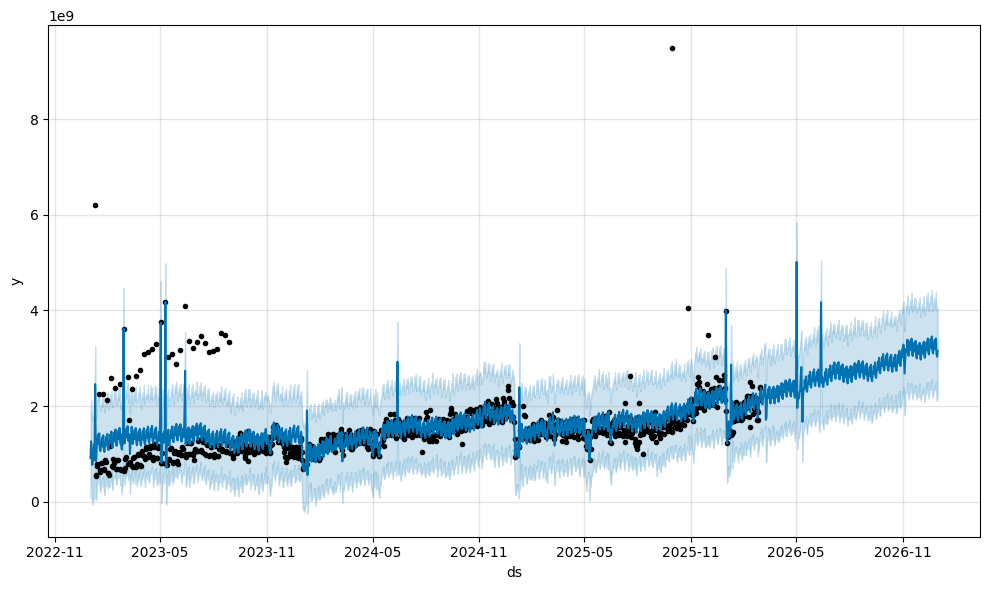

In [296]:
model_old = Prophet(holidays=holidays_df,
            weekly_seasonality= True,
            yearly_seasonality= True,
            daily_seasonality= True,
            #changepoint_prior_scale= 0.05,
            interval_width= 0.95,)
model_old.fit(df_prophet_eacq_CIB)
future = pd.DataFrame({'ds': pd.date_range(start="2023-01-01", end="2026-12-31", freq='D')})
future.tail()
forecast_eacq_old = model_old.predict(future)
fig1 = model_old.plot(forecast_eacq_old)
#fig2 = model_old.plot_components(forecast_eacq_old)

# для неоптимиированной Prophet

y_true = df_prophet_eacq['y'].values
y_pred = forecast_eacq_CIB['yhat'][:len(df_prophet_eacq_CIB)].values

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

print(f"{'R²':<25} | {r2:^12.3f}")
print(f"{'MAE (тыс. руб.)':<25} | {mae/1000:^12,.0f}")
print(f"{'MAPE (%)':<25} | {mape:^12.1f}")
print(f"{'RMSE (тыс.)':<25} | {rmse/1000:^12.1f}")

R²                        |    0.716    
MAE (тыс. руб.)           |    65,018   
MAPE (%)                  |     13.7    
RMSE (тыс.)               |   95441.5   


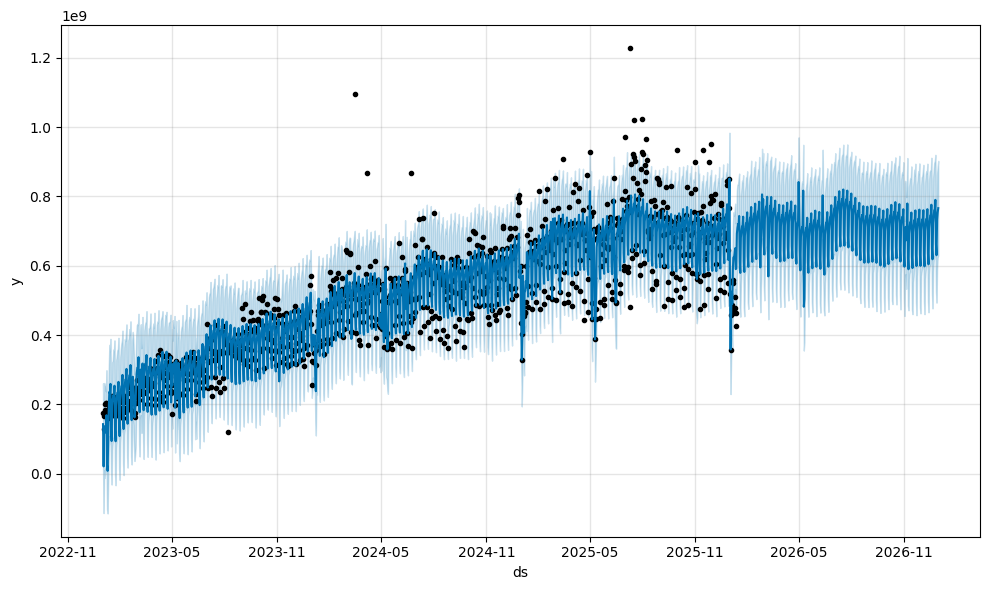

In [264]:
model_old = Prophet(holidays=holidays_df,
            weekly_seasonality= True,
            yearly_seasonality= True,
            daily_seasonality= True,
            #changepoint_prior_scale= 0.05,
            interval_width= 0.95,)
model_old.fit(df_prophet_eacq)
future = pd.DataFrame({'ds': pd.date_range(start="2023-01-01", end="2026-12-31", freq='D')})
future.tail()
forecast_eacq_old = model_old.predict(future)
fig1 = model_old.plot(forecast_eacq_old)
#fig2 = model_old.plot_components(forecast_eacq_old)

# для неоптимиированной Prophet

y_true = df_prophet_eacq['y'].values
y_pred = forecast_eacq_old['yhat'][:len(df_prophet_eacq)].values

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

print(f"{'R²':<25} | {r2:^12.3f}")
print(f"{'MAE (тыс. руб.)':<25} | {mae/1000:^12,.0f}")
print(f"{'MAPE (%)':<25} | {mape:^12.1f}")
print(f"{'RMSE (тыс.)':<25} | {rmse/1000:^12.1f}")

In [96]:
def add_regressors(df: pd.DataFrame) -> pd.DataFrame:
    """Add custom regressors, e.g., special Thursday and summer season"""
    df['ds'] = pd.to_datetime(df['ds'])
    df['summer_season'] = df['ds'].dt.month.isin([6, 7, 8]).astype(int)
    return df

df.head()    

,VALUE_DAY,FEE_RUR_AMT_SUM
0,2023-01-01,1.759940e+08
1,2023-01-02,1.297660e+08
2,2023-01-03,1.655260e+08
3,2023-01-04,1.838775e+08
4,2023-01-05,2.022027e+08


100%|██████████| 21/21 [00:06<00:00,  3.37it/s]
13:51:27 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
  0%|          | 0/21 [00:00<?, ?it/s]13:51:50 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
 29%|██▊       | 6/21 [00:04<00:05,  2.54it/s]13:51:55 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
 71%|███████▏  | 15/21 [00:10<00:01,  3.12it/s]13:52:00 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
  0%|          | 0/21 [00:00<?, ?it/s]13:53:31 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
  0%|          | 0/21 [00:00<?, ?it/s]13:54:05 -

R²                        |    0.709    
MAE (тыс. руб.)           |    63,677   
MAPE (%)                  |     12.7    
RMSE (тыс.)               |   96578.1   


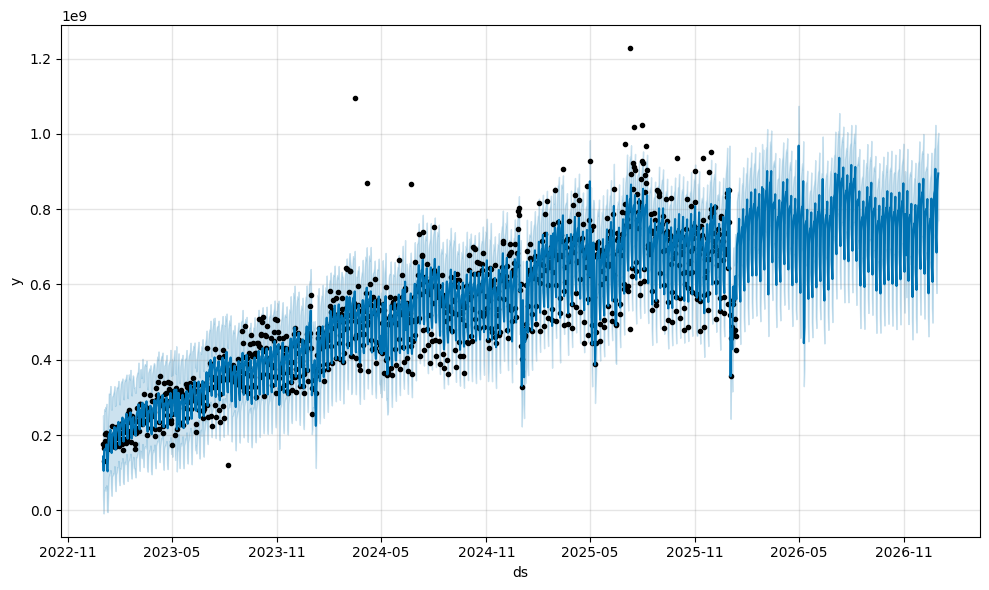

In [277]:
# 0. Полностью отключаем логи Optuna (кроме ошибок)
optuna.logging.set_verbosity(optuna.logging.ERROR)
logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
set_verbosity(optuna.logging.WARNING)


def run_optuna_search_revenue_cv(df_prophet_eacq, n_trials: int = 50, metric: str = {"mae", "mape","r2", "rmse"}) -> Dict:
    optuna.logging.set_verbosity(optuna.logging.ERROR)
    logging.basicConfig(level=logging.ERROR)
    warnings.filterwarnings("ignore")
    logging.getLogger('prophet').setLevel(logging.ERROR)
    logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
    set_verbosity(optuna.logging.WARNING)
    """Optimize Prophet hyperparameters using Optuna"""

    def objective(trial):
        # Suggest hyperparameters
        params = {
            "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
            "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True),
            "holidays_prior_scale": trial.suggest_float("holidays_prior_scale", 0.01, 10.0, log=True),
            "seasonality_mode": trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
            "n_changepoints": trial.suggest_int("n_changepoints", 10, 50),
            "changepoint_range": trial.suggest_float("changepoint_range", 0.8, 0.95),
            #'weekly_seasonality': trial.suggest_categorical('weekly_seasonality', [True, False]),
            #'yearly_seasonality': trial.suggest_categorical('yearly_seasonality', [True, False]),
            #'daily_seasonality': trial.suggest_categorical('daily_seasonality', [True, False]),
        }

        df_train = add_regressors(df_prophet_eacq.copy())
        model = Prophet(
            holidays=holidays_df,
            weekly_seasonality=True,
            daily_seasonality=False,
            yearly_seasonality=False,
            interval_width=0.95,
            **params
        )
        # Optional seasonalities
        model.add_seasonality(name='yearly', period=365.25, fourier_order=3)
        model.add_seasonality(name='yearly_alt', period=365.25, fourier_order=15)

        # Fit model
        model.fit(df_train)

        # Cross-validation
        df_cv = cross_validation(model
                                 , initial="366 days"
                                 , period="31 days"
                                 , horizon="91 days"
                                 , parallel= None #"processes"
                                )
        y_true = df_cv["y"].values
        y_pred = df_cv["yhat"].values

        return LOSS_FUNCS[metric](y_true, y_pred)

    study = optuna.create_study(direction= "maximize")
    study.optimize(objective, n_trials=n_trials)
    
    return study.best_params


# После получения best_params из run_optuna_search_revenue_cv
best_params = run_optuna_search_revenue_cv(df_prophet_eacq, n_trials=50, metric= "r2")

# Создаем модель с лучшими параметрами
model = Prophet(
    holidays=holidays_df,
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False,
    interval_width=0.95,
    **best_params
)

# Добавляем сезонности вручную (как в objective)
model.add_seasonality(name='yearly', period=365.25, fourier_order=3)
model.add_seasonality(name='yearly_alt', period=365.25, fourier_order=15)

# Обучаем модель на всех данных
df_train = add_regressors(df_prophet_eacq.copy())
model.fit(df_train.rename(columns={"ds": "ds", "y": "y"}))

# Создаем future dataframe
future = pd.DataFrame({'ds': pd.date_range(start="2023-01-01", end="2026-12-31", freq='D')})

# Прогнозируем
forecast_eacq = model.predict(future)

# Визуализация
fig1 = model.plot(forecast_eacq)

y_true = df_prophet_eacq['y'].values
y_pred = forecast_eacq['yhat'][:len(df_prophet_eacq)].values

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

print(f"{'R²':<25} | {r2:^12.3f}")
print(f"{'MAE (тыс. руб.)':<25} | {mae/1000:^12,.0f}")
print(f"{'MAPE (%)':<25} | {mape:^12.1f}")
print(f"{'RMSE (тыс.)':<25} | {rmse/1000:^12.1f}")

In [279]:
# для графиков 
forecast_eacq['year_month'] = forecast_eacq['ds'].dt.to_period('M')
forecast_eacq_old['year_month'] = forecast_eacq_old['ds'].dt.to_period('M')
forecast_eacq_old.rename(columns={'yhat': 'y_old'}, inplace=True)

df_merged = forecast_eacq[['ds', 'year_month', 'yhat']].merge(
    forecast_eacq_old[['y_old','ds']],
    on='ds',
    how='left'  # чтобы сохранить все даты из прогноза (включая будущие)
)

df_merged.head()

,ds,year_month,yhat,y_old
0,2023-01-01,2023-01,1.429382e+08,1.429608e+08
1,2023-01-02,2023-01,1.047896e+08,2.108108e+07
2,2023-01-03,2023-01,1.597881e+08,1.370509e+08
3,2023-01-04,2023-01,1.617883e+08,1.181108e+08
4,2023-01-05,2023-01,1.641705e+08,1.294636e+08


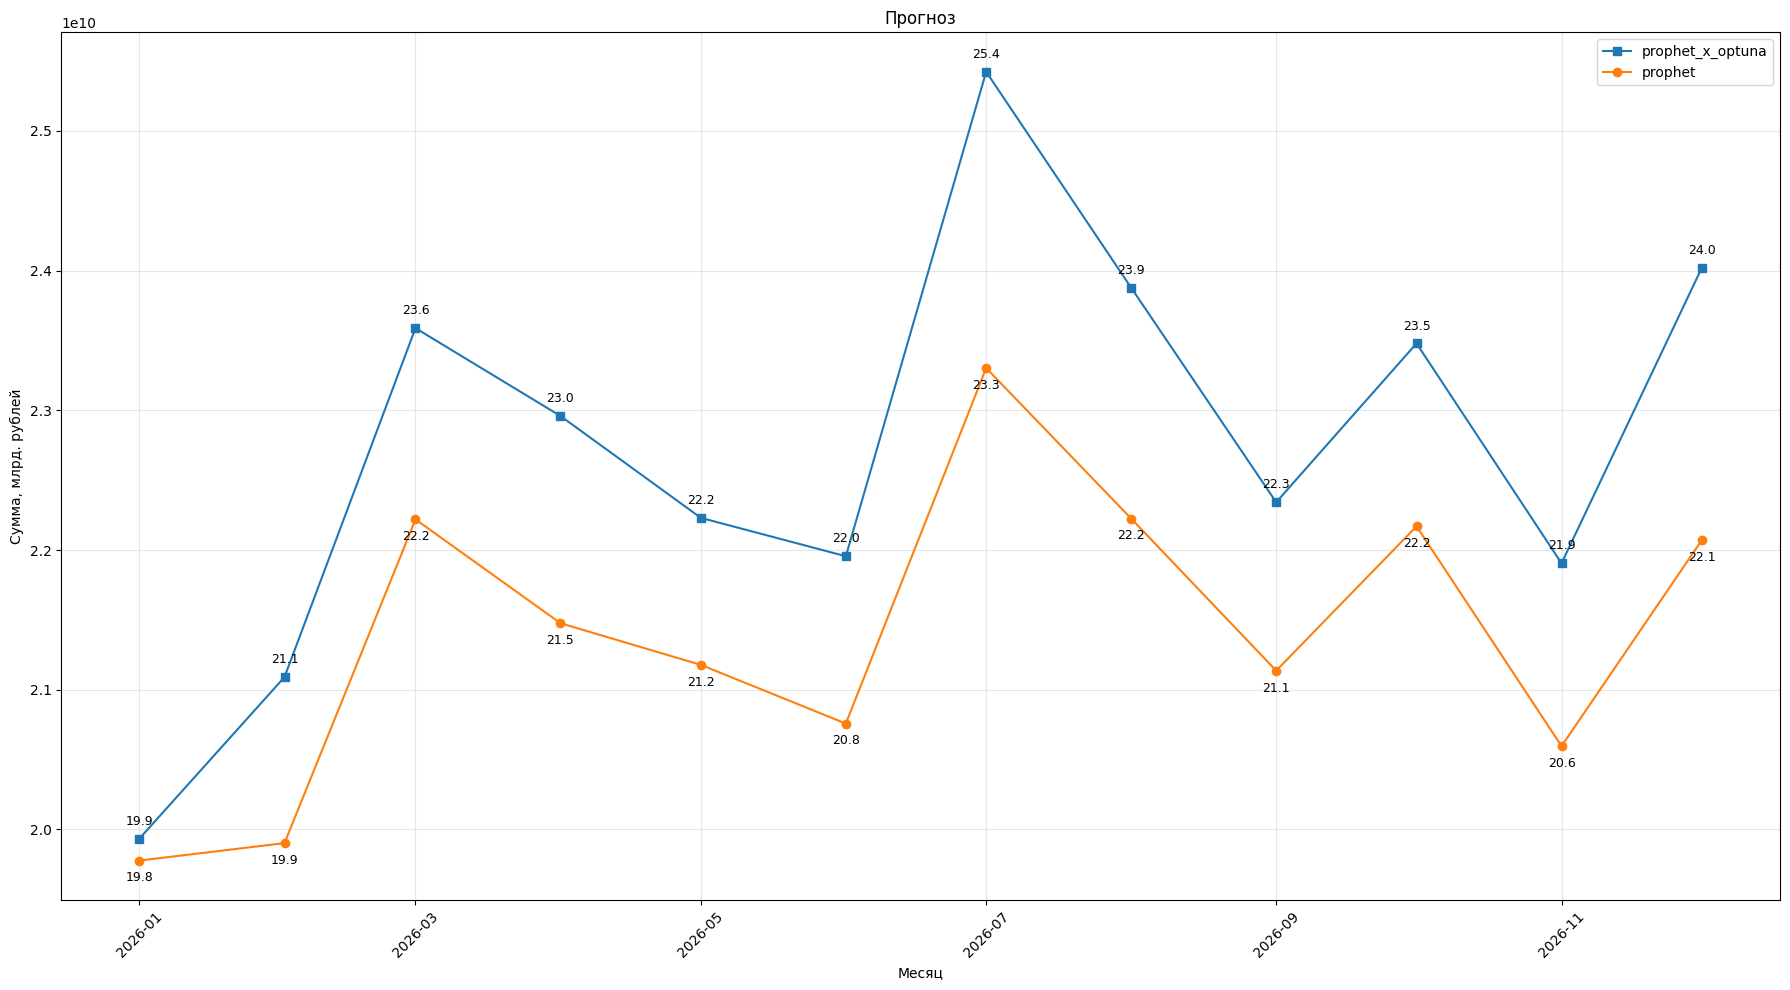

In [280]:
# Агрегируем по месяцам
df_monthly = df_merged.groupby('year_month')[['yhat', 'y_old']].sum().reset_index()
df_monthly['year_month'] = df_monthly['year_month'].dt.to_timestamp()  # преобразуем в datetime для графика
df_monthly = df_monthly[df_monthly['year_month'] > '2025-12']

# Построение графика
plt.figure(figsize=(18, 10))
plt.plot(df_monthly['year_month'], df_monthly['yhat'], label='prophet_x_optuna', marker='s', zorder=2)
plt.plot(df_monthly['year_month'], df_monthly['y_old'], label='prophet', marker='o', zorder=3)

plt.title('Прогноз')
plt.xlabel('Месяц')
plt.ylabel('Сумма, млрд. рублей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Добавление подписей значений на график
for i, row in df_monthly.iterrows():
    x = row['year_month']
    # prophet_x_optuna (yhat) — сверху
    plt.annotate(f"{row['yhat']/1e9:.1f}", 
                 (x, row['yhat']), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 fontsize=9, 
                 zorder=5)
    # prophet (y_old) — снизу
    plt.annotate(f"{row['y_old']/1e9:.1f}", 
                 (x, row['y_old']), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 ha='center', 
                 fontsize=9, 
                 zorder=5)

plt.tight_layout()
plt.show()

In [268]:
def load_and_preprocess(path):
    try:
        df = pd.read_excel(path)
        
        if 'VALUE_DAY' not in df.columns or 'FEE_RUR_AMT_SUM' not in df.columns:
            raise ValueError("Файл должен содержать колонки 'VALUE_DAY' и 'FEE_RUR_AMT_SUM'")
            
        df['VALUE_DAY'] = pd.to_datetime(df['VALUE_DAY'], errors='coerce')
        df = df.dropna(subset=['VALUE_DAY'])
        
        df = df.groupby('VALUE_DAY', as_index=False)['FEE_RUR_AMT_SUM'].sum()
        
        min_date = df['VALUE_DAY'].min()
        max_date = df['VALUE_DAY'].max()
        full_dates = pd.date_range(start=min_date, end=max_date, freq='D')
        
        full_df = pd.DataFrame({'VALUE_DAY': full_dates})
        result = pd.merge(full_df, df, on='VALUE_DAY', how='left')
        
        result['FEE_RUR_AMT_SUM'] = result['FEE_RUR_AMT_SUM'].fillna(0).clip(lower=0)
        
        return result[['VALUE_DAY', 'FEE_RUR_AMT_SUM']]
    
    except Exception as e:
        print(f"Ошибка загрузки данных: {e}")
        return None

def create_features(data):
    data = data.sort_values('VALUE_DAY').copy()
    
    data['days_since_start'] = (data['VALUE_DAY'] - data['VALUE_DAY'].min()).dt.days
    data['month'] = data['VALUE_DAY'].dt.month
    data['quarter'] = data['VALUE_DAY'].dt.quarter
    data['day_of_week'] = data['VALUE_DAY'].dt.dayofweek
    data['is_weekend'] = data['day_of_week'].isin([5,6]).astype(int)
    data['is_month_end'] = data['VALUE_DAY'].dt.is_month_end.astype(int)
    data['is_holiday'] = 0
    
    return data

def build_model(data):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    poly_features = poly.fit_transform(data[['days_since_start']])
    poly_columns = poly.get_feature_names_out(['days_since_start'])
    
    X_poly = pd.DataFrame(poly_features, columns=poly_columns)
    features = ['month', 'quarter', 'day_of_week', 'is_weekend', 'is_month_end', 'is_holiday']
    X = pd.concat([X_poly, data[features]], axis=1)
    
    y = data['FEE_RUR_AMT_SUM']
    
    model = LinearRegression()
    model.fit(X, y)
    
    data['predicted'] = model.predict(X)
    mae = mean_absolute_error(y, data['predicted'])
    mape = mean_absolute_percentage_error(y, data['predicted']) * 100
    r2 = r2_score(y, data['predicted'])
    
    return model, poly, mae, mape, r2

def generate_forecast(model, poly, last_date, data_start_date):
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        end='2026-12-31'
    )
    print(future_dates)
    
    future_data = pd.DataFrame({'VALUE_DAY': future_dates})
    
    future_data['days_since_start'] = (future_data['VALUE_DAY'] - data_start_date).dt.days
    future_data['month'] = future_data['VALUE_DAY'].dt.month
    future_data['quarter'] = future_data['VALUE_DAY'].dt.quarter
    future_data['day_of_week'] = future_data['VALUE_DAY'].dt.dayofweek
    future_data['is_weekend'] = future_data['day_of_week'].isin([5,6]).astype(int)
    future_data['is_month_end'] = future_data['VALUE_DAY'].dt.is_month_end.astype(int)
    future_data['is_holiday'] = 0
    
    poly_features = poly.transform(future_data[['days_since_start']])
    X_poly = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(['days_since_start']))
    
    features = ['month', 'quarter', 'day_of_week', 'is_weekend', 'is_month_end', 'is_holiday']
    X_future = pd.concat([X_poly, future_data[features]], axis=1)
    
    future_data['forecast'] = model.predict(X_future)
    
    
    return future_data[['VALUE_DAY', 'forecast']]


def main():
    END_DATE = pd.to_datetime('2026-12-31')
    FORECAST_START = pd.to_datetime('2023-01-01')
    data = load_and_preprocess(file_path_eacq)
    if data is None:
        return

    data = create_features(data)
    mindate = data['VALUE_DAY'].min()
    
    model, poly, mae_reg, mape_reg, r2_reg = build_model(data)
    
    data_start_date = data['VALUE_DAY'].min()
    last_date = data['VALUE_DAY'].max()
    regression_forecast = generate_forecast(model, poly, last_date, data_start_date)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            ts_data = data['FEE_RUR_AMT_SUM'] + 1e-6
            
            ets_model = ExponentialSmoothing(
                ts_data,
                trend='add',
                seasonal='add',
                seasonal_periods= 365, # пока оптмиально для сезонности
                use_boxcox=True
            ).fit()
            
            data['ets_predicted'] = np.clip(ets_model.fittedvalues - 1e-6, a_min=0, a_max=None)
            forecast_steps = len(regression_forecast)
            ets_forecast_values = ets_model.forecast(forecast_steps).values - 1e-6
            
        except Exception as e:
            print(f"Ошибка в ETS модели: {e}")
            data['ets_predicted'] = 0
            ets_forecast_values = np.zeros(len(regression_forecast))
    
    es_forecast = pd.DataFrame({
        'VALUE_DAY': regression_forecast['VALUE_DAY'],
        'ets_forecast': np.clip(ets_forecast_values, a_min=0, a_max=None)
    })
        # Прогнозные данные
    def extend_forecast(df, end_date):
        last_date = df['VALUE_DAY'].max()
        if last_date < end_date:
            extension = pd.date_range(
                start=last_date + pd.DateOffset(1),
                end=end_date,
                freq='D'
            ).to_series().reset_index(name='VALUE_DAY')
            extension['predicted'] = np.nan
            return pd.concat([df, extension[['VALUE_DAY', 'predicted']]])
        return df
        
    monthly_ets = pd.concat([data[['VALUE_DAY', 'ets_predicted']], 
                           es_forecast.rename(columns={'ets_forecast':'ets_predicted'})]
                         ).pipe(extend_forecast, END_DATE)
    
    ets_new = pd.DataFrame({
        'VALUE_DAY': regression_forecast['VALUE_DAY'],
        'ets_forecast': np.clip(ets_forecast_values, a_min=0, a_max=None)
    })
    
    # Расчет метрик для ETS модели
    r2_es = r2_score(data['FEE_RUR_AMT_SUM'], data['ets_predicted'])
    mae_es = mean_absolute_error(data['FEE_RUR_AMT_SUM'], data['ets_predicted'])
    mape_es = mean_absolute_percentage_error(data['FEE_RUR_AMT_SUM'], data['ets_predicted']) * 100
    
    print("\nСравнение моделей:")
    print(f"{'Метрика':<25} | {'Регрессия':^12} | {'ETS модель':^12}")
    print("-"*50)
    print(f"{'R²':<25} | {r2_reg:^12.3f} | {r2_es:^12.3f}")
    print(f"{'MAE (тыс. руб.)':<25} | {mae_reg/1000:^12,.0f} | {mae_es/1000:^12,.0f}")
    print(f"{'MAPE (%)':<25} | {mape_reg:^12.1f} | {mape_es:^12.1f}")

    print(data['ets_predicted'])
    
    full_forecast = pd.merge(
        regression_forecast[['VALUE_DAY', 'forecast']],
        es_forecast[['VALUE_DAY', 'ets_forecast']],
        on='VALUE_DAY'
    )
    full_forecast.columns = ['Дата', 'Прогноз регрессии', 'ETS прогноз']
    full_forecast.to_excel('comparison_forecast_eacq_ozon_full.xlsx', index=False)
    print("\nПрогнозы сохранены в файл: comparison_forecast_eacq_zozn_full.xlsx")
    return monthly_ets
if __name__ == "__main__":
    main()
es_forecastdf = main()

DatetimeIndex(['2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16',
               '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22',
               ...
               '2026-12-22', '2026-12-23', '2026-12-24', '2026-12-25',
               '2026-12-26', '2026-12-27', '2026-12-28', '2026-12-29',
               '2026-12-30', '2026-12-31'],
              dtype='datetime64[us]', length=353, freq='D')

Сравнение моделей:
Метрика                   |  Регрессия   |  ETS модель 
--------------------------------------------------
R²                        |    0.726     |    0.807    
MAE (тыс. руб.)           |    66,932    |    55,102   
MAPE (%)                  | 518365782912757596684288.0 | 174170310854158441250816.0
0       2.674583e+08
1       1.676635e+08
2       1.525683e+08
3       1.906986e+08
4       2.307420e+08
            ...     
1103    5.385469e+08
1104    5.809266e+08
1105    6.606115e+08
1106    6.798497e+08
1107    6.002344e

In [269]:
main()

DatetimeIndex(['2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16',
               '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22',
               ...
               '2026-12-22', '2026-12-23', '2026-12-24', '2026-12-25',
               '2026-12-26', '2026-12-27', '2026-12-28', '2026-12-29',
               '2026-12-30', '2026-12-31'],
              dtype='datetime64[us]', length=353, freq='D')

Сравнение моделей:
Метрика                   |  Регрессия   |  ETS модель 
--------------------------------------------------
R²                        |    0.726     |    0.807    
MAE (тыс. руб.)           |    66,932    |    55,102   
MAPE (%)                  | 518365782912757596684288.0 | 174170310854158441250816.0
0       2.674583e+08
1       1.676635e+08
2       1.525683e+08
3       1.906986e+08
4       2.307420e+08
            ...     
1103    5.385469e+08
1104    5.809266e+08
1105    6.606115e+08
1106    6.798497e+08
1107    6.002344e

,VALUE_DAY,ets_predicted
0,2023-01-01,2.674583e+08
1,2023-01-02,1.676635e+08
2,2023-01-03,1.525683e+08
3,2023-01-04,1.906986e+08
4,2023-01-05,2.307420e+08
...,...,...
348,2026-12-27,8.080237e+08
349,2026-12-28,8.810230e+08
350,2026-12-29,8.869397e+08
351,2026-12-30,6.989795e+08


In [281]:
es_forecastdf.rename(columns={'VALUE_DAY': 'ds'}, inplace=True)

print(es_forecastdf['ds'].min())


2023-01-01 00:00:00


In [282]:
warnings.filterwarnings("ignore")
eacq_fact = r'data_eacq_SKB_fact.xlsx' 
df_fact = pd.read_excel(eacq_fact)
df_fact.rename(columns={'VALUE_DAY': 'ds'}, inplace=True)
df_fact.head()

,ds,FEE_RUR_AMT_SUM
0,2023-01-01,1.759940e+08
1,2023-01-02,1.297660e+08
2,2023-01-03,1.655260e+08
3,2023-01-04,1.838775e+08
4,2023-01-05,2.022027e+08


In [283]:
es_forecastdf['year_month'] = es_forecastdf['ds'].dt.to_period('M')
es_forecastdf.head()

,ds,ets_predicted,year_month
0,2023-01-01,2.674583e+08,2023-01
1,2023-01-02,1.676635e+08,2023-01
2,2023-01-03,1.525683e+08,2023-01
3,2023-01-04,1.906986e+08,2023-01
4,2023-01-05,2.307420e+08,2023-01


In [284]:
es_forecastdf['year_month'] = es_forecastdf['ds'].dt.to_period('M')

df_merged_x_ets = df_merged[['ds', 'year_month', 'yhat', 'y_old']].merge(
    es_forecastdf[['ds','ets_predicted']],
    on='ds',
    how='inner'  # чтобы сохранить все даты из прогноза (включая будущие)
)

df_merged_x_ets.head()
print(df_merged_x_ets['ds'].min())

2023-01-01 00:00:00


In [274]:
df_fact.head()

,ds,FEE_RUR_AMT_SUM
0,2023-01-01,1.759940e+08
1,2023-01-02,1.297660e+08
2,2023-01-03,1.655260e+08
3,2023-01-04,1.838775e+08
4,2023-01-05,2.022027e+08


In [285]:
df_merged_x_fact = df_merged_x_ets[['ds', 'year_month', 'yhat', 'y_old','ets_predicted']].merge(
    df_fact[['ds','FEE_RUR_AMT_SUM']],
    on='ds',
    how='left'  # чтобы сохранить все даты из прогноза (включая будущие)
)

df_merged_x_fact.head()

,ds,year_month,yhat,y_old,ets_predicted,FEE_RUR_AMT_SUM
0,2023-01-01,2023-01,1.429382e+08,1.429608e+08,2.674583e+08,1.759940e+08
1,2023-01-02,2023-01,1.047896e+08,2.108108e+07,1.676635e+08,1.297660e+08
2,2023-01-03,2023-01,1.597881e+08,1.370509e+08,1.525683e+08,1.655260e+08
3,2023-01-04,2023-01,1.617883e+08,1.181108e+08,1.906986e+08,1.838775e+08
4,2023-01-05,2023-01,1.641705e+08,1.294636e+08,2.307420e+08,2.022027e+08


In [147]:
#rint(df_merged_x_fact['ds'].min())
#print(df['VALUE_DAY'].min())


print(es_forecastdf['ds'].max())
print(df_merged_x_fact['ds'].max())
print(forecast_eacq['ds'].max())



2026-12-31 00:00:00
2026-12-31 00:00:00
2026-12-31 00:00:00


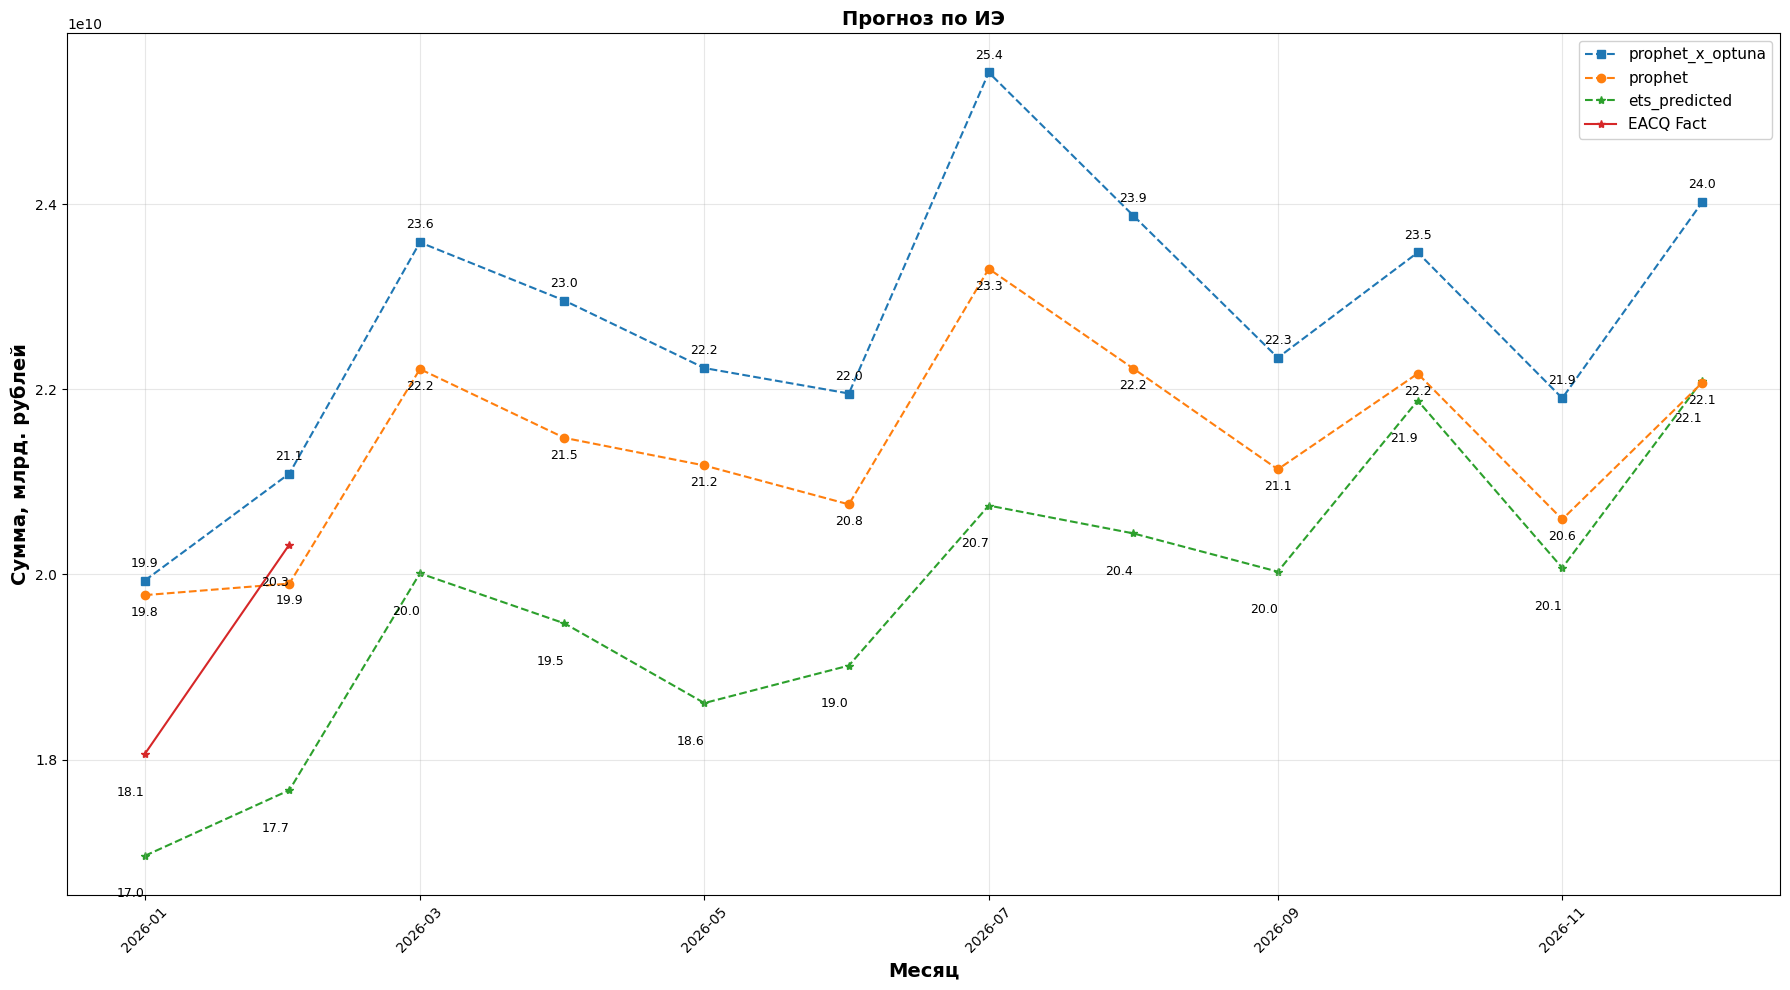

In [291]:
# Агрегируем по месяцам
df_monthly = df_merged_x_fact.groupby('year_month')[['yhat', 'y_old', 'ets_predicted','FEE_RUR_AMT_SUM']].sum().reset_index()
df_monthly['year_month'] = df_monthly['year_month'].dt.to_timestamp()  # преобразуем в datetime для графика
df_monthly = df_monthly[df_monthly['year_month'] > '2025-12-01']
df_filtered = df_monthly[df_monthly['year_month'] < '2026-03-01']


# Построение графика
plt.figure(figsize=(18, 10))
plt.plot(df_monthly['year_month'], df_monthly['yhat'], label='prophet_x_optuna', marker='s', linestyle='dashed',zorder=2)
plt.plot(df_monthly['year_month'], df_monthly['y_old'], label='prophet', marker='o', linestyle='dashed', zorder=3)
plt.plot(df_monthly['year_month'], df_monthly['ets_predicted'], label='ets_predicted', marker='*', linestyle='dashed',zorder=1)
plt.plot(df_filtered['year_month'], df_filtered['FEE_RUR_AMT_SUM'], label='EACQ Fact', marker='*',zorder=5)

plt.title('Прогноз по ИЭ', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=14, fontweight='bold')
plt.ylabel('Сумма, млрд. рублей', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Добавление подписей значений на график
for i, row in df_monthly.iterrows():
    x = row['year_month']
    # prophet_x_optuna (yhat) — сверху
    plt.annotate(f"{row['yhat']/1e9:.1f}", 
                 (x, row['yhat']), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 fontsize=9, 
                 zorder=5)
    # prophet (y_old) — снизу
    plt.annotate(f"{row['y_old']/1e9:.1f}", 
                 (x, row['y_old']), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 ha='center', 
                 fontsize=9, 
                 zorder=5)
    # ets_forecast — ещё ниже, чтобы не наложилось
    plt.annotate(f"{row['ets_predicted']/1e9:.1f}", 
                 (x, row['ets_predicted']), 
                 textcoords="offset points", 
                 xytext=(0, -30), 
                 ha='right', 
                 fontsize=9, 
                 #color='purple', 
                 zorder=5)
    # ets_forecast — ещё ниже, чтобы не наложилось
    plt.annotate(f"{row['FEE_RUR_AMT_SUM']/1e9:.1f}", 
                 (x, row['FEE_RUR_AMT_SUM']), 
                 textcoords="offset points", 
                 xytext=(0, -30), 
                 ha='right', 
                 fontsize=9, 
                 #color='purple', 
                 zorder=5)
plt.tight_layout()
plt.show()

In [290]:
y_true = df_fact['FEE_RUR_AMT_SUM'].values
y_pred_prophet = forecast_eacq['yhat'][:len(df_fact)].values
y_pred_prophet_old = forecast_eacq_old['y_old'][:len(df_fact)].values
y_pred_ets = es_forecastdf['ets_predicted'][:len(df_fact)].values


# 1. Метрики для Prophet (Оптимизированный)
r2_prophet = r2_score(y_true, y_pred_prophet)
mae_prophet = mean_absolute_error(y_true, y_pred_prophet)
mape_prophet = mean_absolute_percentage_error(y_true, y_pred_prophet) * 100
rmse_prophet = np.sqrt(np.mean((y_pred_prophet - y_true) ** 2))

# 2. Метрики для Prophet (Базовый/Обычный)
r2_prophet_old = r2_score(y_true, y_pred_prophet_old)
mae_prophet_old = mean_absolute_error(y_true, y_pred_prophet_old)
mape_prophet_old = mean_absolute_percentage_error(y_true, y_pred_prophet_old) * 100
rmse_prophet_old = np.sqrt(np.mean((y_pred_prophet_old - y_true) ** 2))

# 3. Метрики для ETS
r2_ets = r2_score(y_true, y_pred_ets)
mae_ets = mean_absolute_error(y_true, y_pred_ets)
mape_ets = mean_absolute_percentage_error(y_true, y_pred_ets) * 100
rmse_ets = np.sqrt(np.mean((y_pred_ets - y_true) ** 2))

# --- Вывод сравнительной таблицы ---

# Определяем ширину колонок для красоты
col_name = 20
col_val = 15

header = f"{'Метрика':<{col_name}} | {'Prophet (Opt)':^{col_val}} | {'Prophet (Base)':^{col_val}} | {'ETS':^{col_val}}"
print(header)
print("-" * len(header))

print(f"{'R²':<{col_name}} | {r2_prophet:^{col_val}.3f} | {r2_prophet_old:^{col_val}.3f} | {r2_ets:^{col_val}.3f}")
print(f"{'MAE (тыс. руб.)':<{col_name}} | {mae_prophet/1000:^{col_val},.0f} | {mae_prophet_old/1000:^{col_val},.0f} | {mae_ets/1000:^{col_val},.0f}")
print(f"{'MAPE (%)':<{col_name}} | {mape_prophet:^{col_val}.1f} | {mape_prophet_old:^{col_val}.1f} | {mape_ets:^{col_val}.1f}")
print(f"{'RMSE (тыс.)':<{col_name}} | {rmse_prophet/1000:^{col_val}.1f} | {rmse_prophet_old/1000:^{col_val}.1f} | {rmse_ets/1000:^{col_val}.1f}")


Метрика              |  Prophet (Opt)  | Prophet (Base)  |       ETS      
--------------------------------------------------------------------------
R²                   |      0.702      |      0.714      |      0.659     
MAE (тыс. руб.)      |     65,111      |     65,973      |     71,870     
MAPE (%)             |      12.8       |      13.7       |      14.2      
RMSE (тыс.)          |     98493.0     |     96542.0     |    105361.0    


In [240]:
file_path_acq = r'ACQ_SKB_tests.xlsx' #r'ACQ_SKB_tests.xlsx' data_ACQ_SKB_full_v2
df_acq = pd.read_excel(file_path_acq)
#df_acq['VALUE_DAY'] = df_acq['VALUE_DAY'].dt.to_period('D')
df_acq.head()
#print(df_acq['VALUE_DAY'].min())
#print(df_acq['VALUE_DAY'].max())
df_prophet_acq = df_acq.copy()  # замените на реальные имена столбцов
df_prophet_acq.rename(columns={'VALUE_DAY': 'ds', 'FEE_RUR_AMT_SUM': 'y'}, inplace=True)
df_prophet_acq.head()

,ds,y
0,2023-01-01,3.386786e+08
1,2023-01-02,1.442741e+08
2,2023-01-03,3.055508e+08
3,2023-01-04,3.696357e+08
4,2023-01-05,4.075563e+08


R²                        |    0.941    
MAE (тыс. руб.)           |    60,236   
MAPE (%)                  |     7.1     
RMSE (тыс.)               |   83348.1   


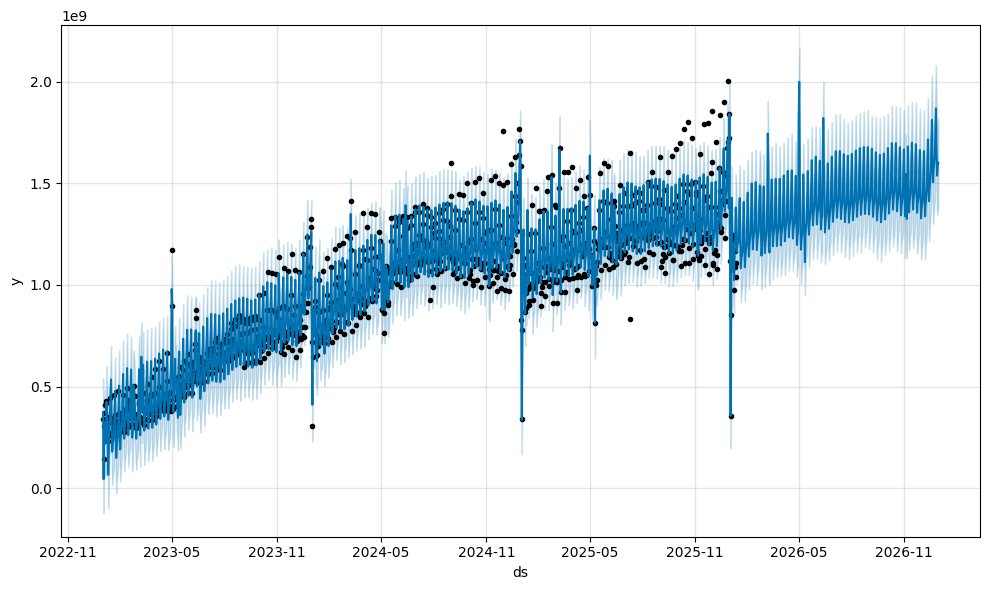

In [241]:
model_old_acq = Prophet(holidays=holidays_df,
            weekly_seasonality= True,
            yearly_seasonality= True,
            daily_seasonality= True,
            #changepoint_prior_scale= 0.05,
            interval_width= 0.95,)
model_old_acq.fit(df_prophet_acq)
future = pd.DataFrame({'ds': pd.date_range(start="2023-01-01", end="2026-12-31", freq='D')})
future.tail()
forecast_acq_old = model_old_acq.predict(future)
fig1 = model_old_acq.plot(forecast_acq_old)
#fig2 = model_old.plot_components(forecast_eacq_old)

# для неоптимиированной Prophet

y_true = df_prophet_acq['y'].values
y_pred = forecast_acq_old['yhat'][:len(df_prophet_acq)].values

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

print(f"{'R²':<25} | {r2:^12.3f}")
print(f"{'MAE (тыс. руб.)':<25} | {mae/1000:^12,.0f}")
print(f"{'MAPE (%)':<25} | {mape:^12.1f}")
print(f"{'RMSE (тыс.)':<25} | {rmse/1000:^12.1f}")

  5%|▍         | 1/21 [00:00<00:02,  6.89it/s]12:40:47 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
 43%|████▎     | 9/21 [00:04<00:03,  3.86it/s]12:40:51 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
  5%|▍         | 1/21 [00:00<00:03,  5.25it/s]12:41:26 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
 43%|████▎     | 9/21 [00:04<00:03,  3.44it/s]12:41:31 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
 57%|█████▋    | 12/21 [00:13<00:12,  1.38s/it]12:41:39 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
  5%|▍         | 1/21 [00:00<00:03

R²                        |    0.947    
MAE (тыс. руб.)           |    56,422   
MAPE (%)                  |     6.6     
RMSE (тыс.)               |   79024.7   


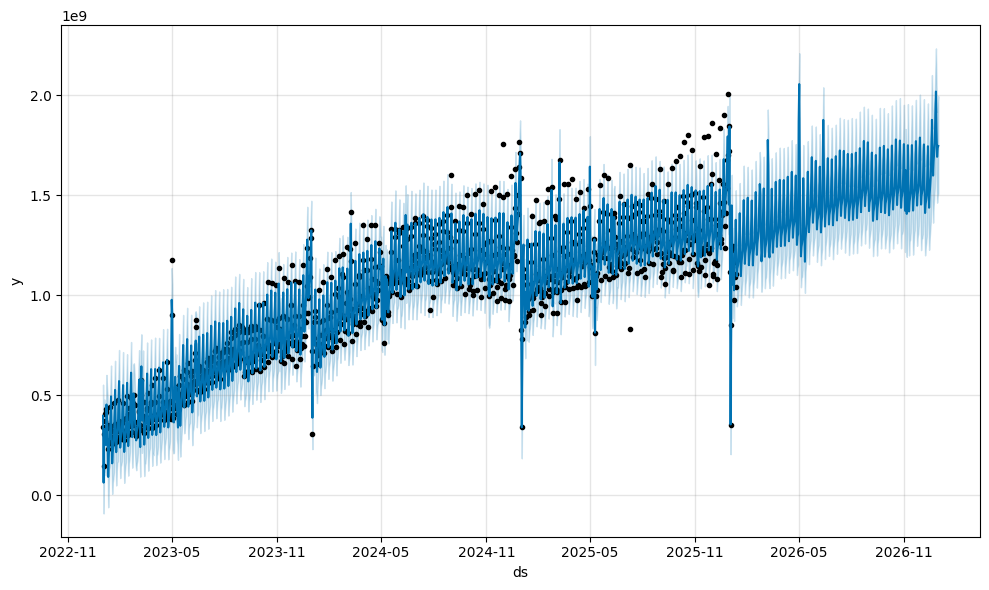

In [242]:
# 0. Полностью отключаем логи Optuna (кроме ошибок)
optuna.logging.set_verbosity(optuna.logging.ERROR)
logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
set_verbosity(optuna.logging.WARNING)


def run_optuna_search_revenue_cv(df_prophet_acq, n_trials: int = 50, metric: str = {"mae", "mape","r2", "rmse"}) -> Dict:
    optuna.logging.set_verbosity(optuna.logging.ERROR)
    logging.basicConfig(level=logging.ERROR)
    warnings.filterwarnings("ignore")
    logging.getLogger('prophet').setLevel(logging.ERROR)
    logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
    set_verbosity(optuna.logging.WARNING)
    """Optimize Prophet hyperparameters using Optuna"""

    def objective(trial):
        # Suggest hyperparameters
        params = {
            "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
            "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True),
            "holidays_prior_scale": trial.suggest_float("holidays_prior_scale", 0.01, 10.0, log=True),
            "seasonality_mode": trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
            "n_changepoints": trial.suggest_int("n_changepoints", 10, 50),
            "changepoint_range": trial.suggest_float("changepoint_range", 0.8, 0.95),
            #'weekly_seasonality': trial.suggest_categorical('weekly_seasonality', [True, False]),
            #'yearly_seasonality': trial.suggest_categorical('yearly_seasonality', [True, False]),
            #'daily_seasonality': trial.suggest_categorical('daily_seasonality', [True, False]),
        }

        df_train = add_regressors(df_prophet_acq.copy())
        model = Prophet(
            holidays=holidays_df,
            weekly_seasonality=True,
            daily_seasonality=False,
            yearly_seasonality=False,
            interval_width=0.95,
            **params
        )
        # Optional seasonalities
        model.add_seasonality(name='yearly', period=365.25, fourier_order=3)
        model.add_seasonality(name='yearly_alt', period=365.25, fourier_order=15)

        # Fit model
        model.fit(df_train)

        # Cross-validation
        df_cv = cross_validation(model
                                 , initial="366 days"
                                 , period="31 days"
                                 , horizon="91 days"
                                 , parallel= None #"processes"
                                )
        y_true = df_cv["y"].values
        y_pred = df_cv["yhat"].values

        return LOSS_FUNCS[metric](y_true, y_pred)

    study = optuna.create_study(direction= "minimize")
    study.optimize(objective, n_trials=n_trials)
    
    return study.best_params


# После получения best_params из run_optuna_search_revenue_cv
best_params = run_optuna_search_revenue_cv(df_prophet_acq, n_trials=50, metric= "mae")

# Создаем модель с лучшими параметрами
model = Prophet(
    holidays=holidays_df,
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False,
    interval_width=0.95,
    **best_params
)

# Добавляем сезонности вручную (как в objective)
model.add_seasonality(name='yearly', period=365.25, fourier_order=3)
model.add_seasonality(name='yearly_alt', period=365.25, fourier_order=15)

# Обучаем модель на всех данных
df_train = add_regressors(df_prophet_acq.copy())
model.fit(df_train.rename(columns={"ds": "ds", "y": "y"}))

# Создаем future dataframe
future = pd.DataFrame({'ds': pd.date_range(start="2023-01-01", end="2026-12-31", freq='D')})

# Прогнозируем
forecast_acq = model.predict(future)

# Визуализация
fig1 = model.plot(forecast_acq)

y_true = df_prophet_acq['y'].values
y_pred = forecast_acq['yhat'][:len(df_prophet_acq)].values

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

print(f"{'R²':<25} | {r2:^12.3f}")
print(f"{'MAE (тыс. руб.)':<25} | {mae/1000:^12,.0f}")
print(f"{'MAPE (%)':<25} | {mape:^12.1f}")
print(f"{'RMSE (тыс.)':<25} | {rmse/1000:^12.1f}")


In [247]:
def load_and_preprocess(path):
    try:
        df = pd.read_excel(path)
        
        if 'VALUE_DAY' not in df.columns or 'FEE_RUR_AMT_SUM' not in df.columns:
            raise ValueError("Файл должен содержать колонки 'VALUE_DAY' и 'FEE_RUR_AMT_SUM'")
            
        df['VALUE_DAY'] = pd.to_datetime(df['VALUE_DAY'], errors='coerce')
        df = df.dropna(subset=['VALUE_DAY'])
        
        df = df.groupby('VALUE_DAY', as_index=False)['FEE_RUR_AMT_SUM'].sum()
        
        min_date = df['VALUE_DAY'].min()
        max_date = df['VALUE_DAY'].max()
        full_dates = pd.date_range(start=min_date, end=max_date, freq='D')
        
        full_df = pd.DataFrame({'VALUE_DAY': full_dates})
        result = pd.merge(full_df, df, on='VALUE_DAY', how='left')
        
        result['FEE_RUR_AMT_SUM'] = result['FEE_RUR_AMT_SUM'].fillna(0).clip(lower=0)
        
        return result[['VALUE_DAY', 'FEE_RUR_AMT_SUM']]
    
    except Exception as e:
        print(f"Ошибка загрузки данных: {e}")
        return None

def create_features(data):
    data = data.sort_values('VALUE_DAY').copy()
    
    data['days_since_start'] = (data['VALUE_DAY'] - data['VALUE_DAY'].min()).dt.days
    data['month'] = data['VALUE_DAY'].dt.month
    data['quarter'] = data['VALUE_DAY'].dt.quarter
    data['day_of_week'] = data['VALUE_DAY'].dt.dayofweek
    data['is_weekend'] = data['day_of_week'].isin([5,6]).astype(int)
    data['is_month_end'] = data['VALUE_DAY'].dt.is_month_end.astype(int)
    data['is_holiday'] = 0
    
    return data

def build_model(data):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    poly_features = poly.fit_transform(data[['days_since_start']])
    poly_columns = poly.get_feature_names_out(['days_since_start'])
    
    X_poly = pd.DataFrame(poly_features, columns=poly_columns)
    features = ['month', 'quarter', 'day_of_week', 'is_weekend', 'is_month_end', 'is_holiday']
    X = pd.concat([X_poly, data[features]], axis=1)
    
    y = data['FEE_RUR_AMT_SUM']
    
    model = LinearRegression()
    model.fit(X, y)
    
    data['predicted'] = model.predict(X)
    mae = mean_absolute_error(y, data['predicted'])
    mape = mean_absolute_percentage_error(y, data['predicted']) * 100
    r2 = r2_score(y, data['predicted'])
    
    return model, poly, mae, mape, r2

def generate_forecast(model, poly, last_date, data_start_date):
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        end='2026-12-31'
    )
    print(future_dates)
    
    future_data = pd.DataFrame({'VALUE_DAY': future_dates})
    
    future_data['days_since_start'] = (future_data['VALUE_DAY'] - data_start_date).dt.days
    future_data['month'] = future_data['VALUE_DAY'].dt.month
    future_data['quarter'] = future_data['VALUE_DAY'].dt.quarter
    future_data['day_of_week'] = future_data['VALUE_DAY'].dt.dayofweek
    future_data['is_weekend'] = future_data['day_of_week'].isin([5,6]).astype(int)
    future_data['is_month_end'] = future_data['VALUE_DAY'].dt.is_month_end.astype(int)
    future_data['is_holiday'] = 0
    
    poly_features = poly.transform(future_data[['days_since_start']])
    X_poly = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(['days_since_start']))
    
    features = ['month', 'quarter', 'day_of_week', 'is_weekend', 'is_month_end', 'is_holiday']
    X_future = pd.concat([X_poly, future_data[features]], axis=1)
    
    future_data['forecast'] = model.predict(X_future)
    
    
    return future_data[['VALUE_DAY', 'forecast']]


def main():
    END_DATE = pd.to_datetime('2026-12-31')
    FORECAST_START = pd.to_datetime('2023-01-01')
    data = df_acq #df_eacq
    if data is None:
        return

    data = create_features(data)
    mindate = data['VALUE_DAY'].min()
    
    model, poly, mae_reg, mape_reg, r2_reg = build_model(data)
    
    data_start_date = data['VALUE_DAY'].min()
    last_date = data['VALUE_DAY'].max()
    regression_forecast = generate_forecast(model, poly, last_date, data_start_date)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            ts_data = data['FEE_RUR_AMT_SUM'] + 1e-6
            
            ets_model = ExponentialSmoothing(
                ts_data,
                trend='add',
                seasonal='add',
                seasonal_periods= 203, # пока оптмиально для сезонности
                use_boxcox=True
            ).fit()
            
            data['ets_predicted'] = np.clip(ets_model.fittedvalues - 1e-6, a_min=0, a_max=None)
            forecast_steps = len(regression_forecast)
            ets_forecast_values = ets_model.forecast(forecast_steps).values - 1e-6
            
        except Exception as e:
            print(f"Ошибка в ETS модели: {e}")
            data['ets_predicted'] = 0
            ets_forecast_values = np.zeros(len(regression_forecast))
    
    es_forecast_acq = pd.DataFrame({
        'VALUE_DAY': regression_forecast['VALUE_DAY'],
        'ets_forecast': np.clip(ets_forecast_values, a_min=0, a_max=None)
    })
        # Прогнозные данные
    def extend_forecast(df, end_date):
        last_date = df['VALUE_DAY'].max()
        if last_date < end_date:
            extension = pd.date_range(
                start=last_date + pd.DateOffset(1),
                end=end_date,
                freq='D'
            ).to_series().reset_index(name='VALUE_DAY')
            extension['predicted'] = np.nan
            return pd.concat([df, extension[['VALUE_DAY', 'predicted']]])
        return df
        
    monthly_ets = pd.concat([data[['VALUE_DAY', 'ets_predicted']], 
                           es_forecast_acq.rename(columns={'ets_forecast':'ets_predicted'})]
                         ).pipe(extend_forecast, END_DATE)
    
    ets_new = pd.DataFrame({
        'VALUE_DAY': regression_forecast['VALUE_DAY'],
        'ets_forecast': np.clip(ets_forecast_values, a_min=0, a_max=None)
    })
    
    # Расчет метрик для ETS модели
    r2_es = r2_score(data['FEE_RUR_AMT_SUM'], data['ets_predicted'])
    mae_es = mean_absolute_error(data['FEE_RUR_AMT_SUM'], data['ets_predicted'])
    mape_es = mean_absolute_percentage_error(data['FEE_RUR_AMT_SUM'], data['ets_predicted']) * 100
    
    print("\nСравнение моделей:")
    print(f"{'Метрика':<25} | {'Регрессия':^12} | {'ETS модель':^12}")
    print("-"*50)
    print(f"{'R²':<25} | {r2_reg:^12.3f} | {r2_es:^12.3f}")
    print(f"{'MAE (тыс. руб.)':<25} | {mae_reg/1000:^12,.0f} | {mae_es/1000:^12,.0f}")
    print(f"{'MAPE (%)':<25} | {mape_reg:^12.1f} | {mape_es:^12.1f}")

    #print(data['ets_predicted'])
    
    full_forecast = pd.merge(
        regression_forecast[['VALUE_DAY', 'forecast']],
        es_forecast_acq[['VALUE_DAY', 'ets_forecast']],
        on='VALUE_DAY'
    )

    return monthly_ets
if __name__ == "__main__":
    main()
es_forecastdf_acq = main()

DatetimeIndex(['2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16',
               '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22',
               ...
               '2026-12-22', '2026-12-23', '2026-12-24', '2026-12-25',
               '2026-12-26', '2026-12-27', '2026-12-28', '2026-12-29',
               '2026-12-30', '2026-12-31'],
              dtype='datetime64[us]', length=353, freq='D')

Сравнение моделей:
Метрика                   |  Регрессия   |  ETS модель 
--------------------------------------------------
R²                        |    0.863     |    0.891    
MAE (тыс. руб.)           |    93,577    |    77,049   
MAPE (%)                  |     10.7     |     9.8     
DatetimeIndex(['2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16',
               '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22',
               ...
               '2026-12-22', '2026-12-23', '2026-12

In [213]:
main()

DatetimeIndex(['2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16',
               '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22',
               ...
               '2026-12-22', '2026-12-23', '2026-12-24', '2026-12-25',
               '2026-12-26', '2026-12-27', '2026-12-28', '2026-12-29',
               '2026-12-30', '2026-12-31'],
              dtype='datetime64[us]', length=353, freq='D')

Сравнение моделей:
Метрика                   |  Регрессия   |  ETS модель 
--------------------------------------------------
R²                        |    0.863     |    0.891    
MAE (тыс. руб.)           |    93,577    |    77,049   
MAPE (%)                  |     10.7     |     9.8     


,VALUE_DAY,ets_predicted
0,2023-01-01,6.912098e+08
1,2023-01-02,3.208592e+08
2,2023-01-03,1.068294e+08
3,2023-01-04,2.246772e+08
4,2023-01-05,3.419970e+08
...,...,...
348,2026-12-27,1.779261e+09
349,2026-12-28,1.538328e+09
350,2026-12-29,1.406451e+09
351,2026-12-30,1.457394e+09


In [248]:
# для графиков 

forecast_acq['year_month'] = forecast_acq['ds'].dt.to_period('M')
forecast_acq_old['year_month'] = forecast_acq_old['ds'].dt.to_period('M')
forecast_acq_old.rename(columns={'yhat': 'y_old'}, inplace=True)

df_merged_acq = forecast_acq[['ds', 'year_month', 'yhat']].merge(
    forecast_acq_old[['y_old','ds']],
    on='ds',
    how='left'  # чтобы сохранить все даты из прогноза (включая будущие)
)

df_merged_acq.head()

,ds,year_month,yhat,y_old
0,2023-01-01,2023-01,3.966805e+08,3.749552e+08
1,2023-01-02,2023-01,6.274613e+07,4.402737e+07
2,2023-01-03,2023-01,3.310011e+08,3.268269e+08
3,2023-01-04,2023-01,2.675630e+08,2.168032e+08
4,2023-01-05,2023-01,2.579559e+08,2.249542e+08


In [249]:
warnings.filterwarnings("ignore")
acq_fact = r'ACQ_SKB_FACT.xlsx' 
df_fact_acq = pd.read_excel(acq_fact)
df_fact_acq.rename(columns={'VALUE_DAY': 'ds'}, inplace=True)
df_fact_acq.head()

,ds,FEE_RUR_AMT_SUM
0,2023-01-01,3.386786e+08
1,2023-01-02,1.442741e+08
2,2023-01-03,3.055508e+08
3,2023-01-04,3.696357e+08
4,2023-01-05,4.075563e+08


In [250]:
es_forecastdf_acq.rename(columns={'VALUE_DAY': 'ds'}, inplace=True)
es_forecastdf_acq['year_month'] = es_forecastdf_acq['ds'].dt.to_period('M')

es_forecastdf_acq.head()

,ds,ets_predicted,year_month
0,2023-01-01,6.912098e+08,2023-01
1,2023-01-02,3.208592e+08,2023-01
2,2023-01-03,1.068294e+08,2023-01
3,2023-01-04,2.246772e+08,2023-01
4,2023-01-05,3.419970e+08,2023-01


In [251]:
es_forecastdf_acq['year_month'] = es_forecastdf_acq['ds'].dt.to_period('M')

df_merged_x_ets_acq = df_merged_acq[['ds', 'year_month', 'yhat', 'y_old']].merge(
    es_forecastdf_acq[['ds','ets_predicted']],
    on='ds',
    how='inner'  # чтобы сохранить все даты из прогноза (включая будущие)
)

df_merged_x_ets_acq.head()
print(df_merged_x_ets_acq['ds'].min())

2023-01-01 00:00:00


In [252]:
df_merged_x_fact_acq = df_merged_x_ets_acq[['ds', 'year_month', 'yhat', 'y_old','ets_predicted']].merge(
    df_fact_acq[['ds','FEE_RUR_AMT_SUM']],
    on='ds',
    how='left'  # чтобы сохранить все даты из прогноза (включая будущие)
)

df_merged_x_fact_acq.head()

,ds,year_month,yhat,y_old,ets_predicted,FEE_RUR_AMT_SUM
0,2023-01-01,2023-01,3.966805e+08,3.749552e+08,6.912098e+08,3.386786e+08
1,2023-01-02,2023-01,6.274613e+07,4.402737e+07,3.208592e+08,1.442741e+08
2,2023-01-03,2023-01,3.310011e+08,3.268269e+08,1.068294e+08,3.055508e+08
3,2023-01-04,2023-01,2.675630e+08,2.168032e+08,2.246772e+08,3.696357e+08
4,2023-01-05,2023-01,2.579559e+08,2.249542e+08,3.419970e+08,4.075563e+08


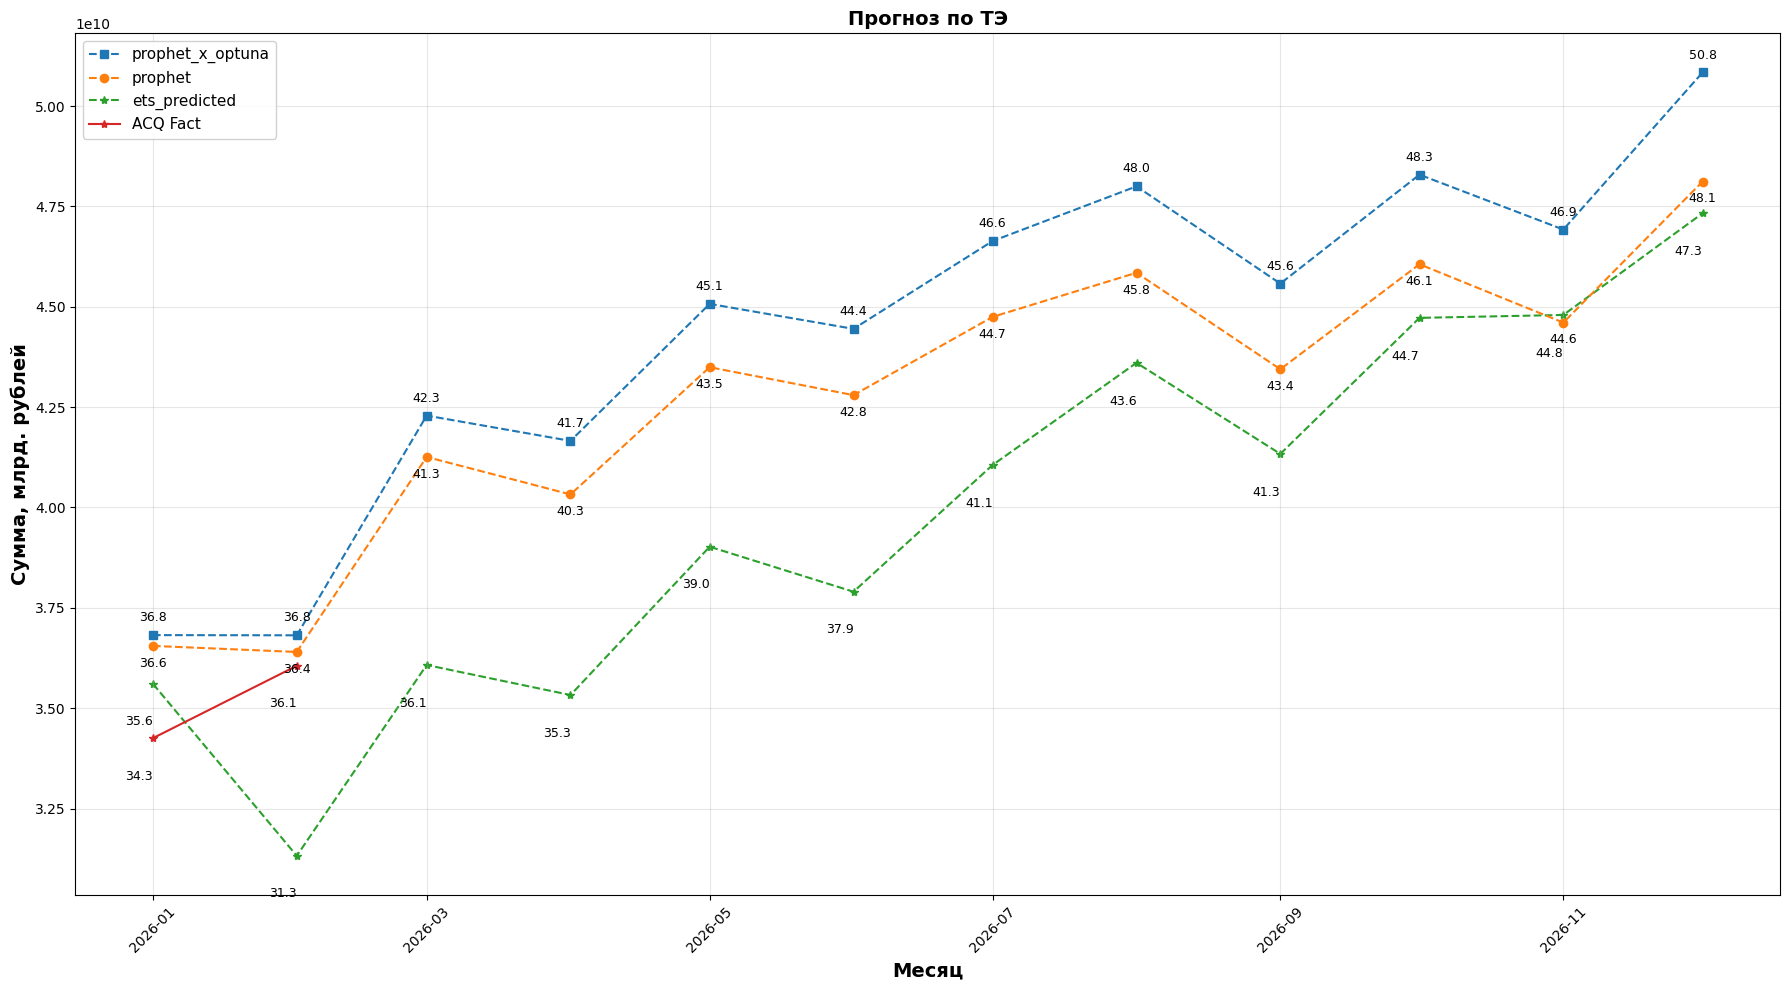

In [253]:
# Агрегируем по месяцам
df_monthly = df_merged_x_fact_acq.groupby('year_month')[['yhat', 'y_old', 'ets_predicted','FEE_RUR_AMT_SUM']].sum().reset_index()
df_monthly['year_month'] = df_monthly['year_month'].dt.to_timestamp()  # преобразуем в datetime для графика
df_monthly = df_monthly[df_monthly['year_month'] > '2025-12-01']
df_filtered = df_monthly[df_monthly['year_month'] < '2026-03-01']


# Построение графика
plt.figure(figsize=(18, 10))
plt.plot(df_monthly['year_month'], df_monthly['yhat'], label='prophet_x_optuna', marker='s', linestyle='dashed',zorder=2)
plt.plot(df_monthly['year_month'], df_monthly['y_old'], label='prophet', marker='o', linestyle='dashed', zorder=3)
plt.plot(df_monthly['year_month'], df_monthly['ets_predicted'], label='ets_predicted', marker='*', linestyle='dashed',zorder=1)
plt.plot(df_filtered['year_month'], df_filtered['FEE_RUR_AMT_SUM'], label='ACQ Fact', marker='*',zorder=5)

plt.title('Прогноз по ТЭ', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=14, fontweight='bold')
plt.ylabel('Сумма, млрд. рублей', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Добавление подписей значений на график
for i, row in df_monthly.iterrows():
    x = row['year_month']
    # prophet_x_optuna (yhat) — сверху
    plt.annotate(f"{row['yhat']/1e9:.1f}", 
                 (x, row['yhat']), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 fontsize=9, 
                 zorder=5)
    # prophet (y_old) — снизу
    plt.annotate(f"{row['y_old']/1e9:.1f}", 
                 (x, row['y_old']), 
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 ha='center', 
                 fontsize=9, 
                 zorder=5)
    # ets_forecast — ещё ниже, чтобы не наложилось
    plt.annotate(f"{row['ets_predicted']/1e9:.1f}", 
                 (x, row['ets_predicted']), 
                 textcoords="offset points", 
                 xytext=(0, -30), 
                 ha='right', 
                 fontsize=9, 
                 #color='purple', 
                 zorder=5)
    # ets_forecast — ещё ниже, чтобы не наложилось
    plt.annotate(f"{row['FEE_RUR_AMT_SUM']/1e9:.1f}", 
                 (x, row['FEE_RUR_AMT_SUM']), 
                 textcoords="offset points", 
                 xytext=(0, -30), 
                 ha='right', 
                 fontsize=9, 
                 #color='purple', 
                 zorder=5)
plt.tight_layout()
plt.show()

In [287]:
y_true = df_fact_acq['FEE_RUR_AMT_SUM'].values
y_pred_prophet = forecast_acq['yhat'][:len(df_fact_acq)].values
y_pred_prophet_old = forecast_acq_old['y_old'][:len(df_fact_acq)].values
y_pred_ets = es_forecastdf_acq['ets_predicted'][:len(df_fact_acq)].values


# 1. Метрики для Prophet (Оптимизированный)
r2_prophet = r2_score(y_true, y_pred_prophet)
mae_prophet = mean_absolute_error(y_true, y_pred_prophet)
mape_prophet = mean_absolute_percentage_error(y_true, y_pred_prophet) * 100
rmse_prophet = np.sqrt(np.mean((y_pred_prophet - y_true) ** 2))

# 2. Метрики для Prophet (Базовый/Обычный)
r2_prophet_old = r2_score(y_true, y_pred_prophet_old)
mae_prophet_old = mean_absolute_error(y_true, y_pred_prophet_old)
mape_prophet_old = mean_absolute_percentage_error(y_true, y_pred_prophet_old) * 100
rmse_prophet_old = np.sqrt(np.mean((y_pred_prophet_old - y_true) ** 2))

# 3. Метрики для ETS
r2_ets = r2_score(y_true, y_pred_ets)
mae_ets = mean_absolute_error(y_true, y_pred_ets)
mape_ets = mean_absolute_percentage_error(y_true, y_pred_ets) * 100
rmse_ets = np.sqrt(np.mean((y_pred_ets - y_true) ** 2))

# --- Вывод сравнительной таблицы ---

# Определяем ширину колонок для красоты
col_name = 20
col_val = 15

header = f"{'Метрика':<{col_name}} | {'Prophet (Opt)':^{col_val}} | {'Prophet (Base)':^{col_val}} | {'ETS':^{col_val}}"
print(header)
print("-" * len(header))

print(f"{'R²':<{col_name}} | {r2_prophet:^{col_val}.3f} | {r2_prophet_old:^{col_val}.3f} | {r2_ets:^{col_val}.3f}")
print(f"{'MAE (тыс. руб.)':<{col_name}} | {mae_prophet/1000:^{col_val},.0f} | {mae_prophet_old/1000:^{col_val},.0f} | {mae_ets/1000:^{col_val},.0f}")
print(f"{'MAPE (%)':<{col_name}} | {mape_prophet:^{col_val}.1f} | {mape_prophet_old:^{col_val}.1f} | {mape_ets:^{col_val}.1f}")
print(f"{'RMSE (тыс.)':<{col_name}} | {rmse_prophet/1000:^{col_val}.1f} | {rmse_prophet_old/1000:^{col_val}.1f} | {rmse_ets/1000:^{col_val}.1f}")


Метрика              |  Prophet (Opt)  | Prophet (Base)  |       ETS      
--------------------------------------------------------------------------
R²                   |      0.939      |      0.932      |      0.874     
MAE (тыс. руб.)      |     59,542      |     63,038      |     80,652     
MAPE (%)             |       6.7       |       7.2       |       9.9      
RMSE (тыс.)          |     84487.6     |     88950.6     |    121398.2    


In [292]:
file_path_CIB_eacq = r'forecast_eacq.xlsx' #r'ACQ_SKB_tests.xlsx' data_ACQ_SKB_full_v2
df_eacq_CIB = pd.read_excel(file_path_CIB_eacq )


In [294]:
def load_and_preprocess(path):
    try:
        df = pd.read_excel(path)
        
        if 'VALUE_DAY' not in df.columns or 'FEE_RUR_AMT_SUM' not in df.columns:
            raise ValueError("Файл должен содержать колонки 'VALUE_DAY' и 'FEE_RUR_AMT_SUM'")
            
        df['VALUE_DAY'] = pd.to_datetime(df['VALUE_DAY'], errors='coerce')
        df = df.dropna(subset=['VALUE_DAY'])
        
        df = df.groupby('VALUE_DAY', as_index=False)['FEE_RUR_AMT_SUM'].sum()
        
        min_date = df['VALUE_DAY'].min()
        max_date = df['VALUE_DAY'].max()
        full_dates = pd.date_range(start=min_date, end=max_date, freq='D')
        
        full_df = pd.DataFrame({'VALUE_DAY': full_dates})
        result = pd.merge(full_df, df, on='VALUE_DAY', how='left')
        
        result['FEE_RUR_AMT_SUM'] = result['FEE_RUR_AMT_SUM'].fillna(0).clip(lower=0)
        
        return result[['VALUE_DAY', 'FEE_RUR_AMT_SUM']]
    
    except Exception as e:
        print(f"Ошибка загрузки данных: {e}")
        return None

def create_features(data):
    data = data.sort_values('VALUE_DAY').copy()
    
    data['days_since_start'] = (data['VALUE_DAY'] - data['VALUE_DAY'].min()).dt.days
    data['month'] = data['VALUE_DAY'].dt.month
    data['quarter'] = data['VALUE_DAY'].dt.quarter
    data['day_of_week'] = data['VALUE_DAY'].dt.dayofweek
    data['is_weekend'] = data['day_of_week'].isin([5,6]).astype(int)
    data['is_month_end'] = data['VALUE_DAY'].dt.is_month_end.astype(int)
    data['is_holiday'] = 0
    
    return data

def build_model(data):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    poly_features = poly.fit_transform(data[['days_since_start']])
    poly_columns = poly.get_feature_names_out(['days_since_start'])
    
    X_poly = pd.DataFrame(poly_features, columns=poly_columns)
    features = ['month', 'quarter', 'day_of_week', 'is_weekend', 'is_month_end', 'is_holiday']
    X = pd.concat([X_poly, data[features]], axis=1)
    
    y = data['FEE_RUR_AMT_SUM']
    
    model = LinearRegression()
    model.fit(X, y)
    
    data['predicted'] = model.predict(X)
    mae = mean_absolute_error(y, data['predicted'])
    mape = mean_absolute_percentage_error(y, data['predicted']) * 100
    r2 = r2_score(y, data['predicted'])
    
    return model, poly, mae, mape, r2

def generate_forecast(model, poly, last_date, data_start_date):
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        end='2026-12-31'
    )
    print(future_dates)
    
    future_data = pd.DataFrame({'VALUE_DAY': future_dates})
    
    future_data['days_since_start'] = (future_data['VALUE_DAY'] - data_start_date).dt.days
    future_data['month'] = future_data['VALUE_DAY'].dt.month
    future_data['quarter'] = future_data['VALUE_DAY'].dt.quarter
    future_data['day_of_week'] = future_data['VALUE_DAY'].dt.dayofweek
    future_data['is_weekend'] = future_data['day_of_week'].isin([5,6]).astype(int)
    future_data['is_month_end'] = future_data['VALUE_DAY'].dt.is_month_end.astype(int)
    future_data['is_holiday'] = 0
    
    poly_features = poly.transform(future_data[['days_since_start']])
    X_poly = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(['days_since_start']))
    
    features = ['month', 'quarter', 'day_of_week', 'is_weekend', 'is_month_end', 'is_holiday']
    X_future = pd.concat([X_poly, future_data[features]], axis=1)
    
    future_data['forecast'] = model.predict(X_future)
    
    
    return future_data[['VALUE_DAY', 'forecast']]


def main():
    END_DATE = pd.to_datetime('2026-12-31')
    FORECAST_START = pd.to_datetime('2023-01-01')
    data = df_eacq_CIB #df_eacq
    if data is None:
        return

    data = create_features(data)
    mindate = data['VALUE_DAY'].min()
    
    model, poly, mae_reg, mape_reg, r2_reg = build_model(data)
    
    data_start_date = data['VALUE_DAY'].min()
    last_date = data['VALUE_DAY'].max()
    regression_forecast = generate_forecast(model, poly, last_date, data_start_date)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            ts_data = data['FEE_RUR_AMT_SUM'] + 1e-6
            
            ets_model = ExponentialSmoothing(
                ts_data,
                trend='add',
                seasonal='add',
                seasonal_periods= 365, # пока оптмиально для сезонности
                use_boxcox=True
            ).fit()
            
            data['ets_predicted'] = np.clip(ets_model.fittedvalues - 1e-6, a_min=0, a_max=None)
            forecast_steps = len(regression_forecast)
            ets_forecast_values = ets_model.forecast(forecast_steps).values - 1e-6
            
        except Exception as e:
            print(f"Ошибка в ETS модели: {e}")
            data['ets_predicted'] = 0
            ets_forecast_values = np.zeros(len(regression_forecast))
    
    es_forecast_acq = pd.DataFrame({
        'VALUE_DAY': regression_forecast['VALUE_DAY'],
        'ets_forecast': np.clip(ets_forecast_values, a_min=0, a_max=None)
    })
        # Прогнозные данные
    def extend_forecast(df, end_date):
        last_date = df['VALUE_DAY'].max()
        if last_date < end_date:
            extension = pd.date_range(
                start=last_date + pd.DateOffset(1),
                end=end_date,
                freq='D'
            ).to_series().reset_index(name='VALUE_DAY')
            extension['predicted'] = np.nan
            return pd.concat([df, extension[['VALUE_DAY', 'predicted']]])
        return df
        
    monthly_ets = pd.concat([data[['VALUE_DAY', 'ets_predicted']], 
                           es_forecast_acq.rename(columns={'ets_forecast':'ets_predicted'})]
                         ).pipe(extend_forecast, END_DATE)
    
    ets_new = pd.DataFrame({
        'VALUE_DAY': regression_forecast['VALUE_DAY'],
        'ets_forecast': np.clip(ets_forecast_values, a_min=0, a_max=None)
    })
    
    # Расчет метрик для ETS модели
    r2_es = r2_score(data['FEE_RUR_AMT_SUM'], data['ets_predicted'])
    mae_es = mean_absolute_error(data['FEE_RUR_AMT_SUM'], data['ets_predicted'])
    mape_es = mean_absolute_percentage_error(data['FEE_RUR_AMT_SUM'], data['ets_predicted']) * 100
    
    print("\nСравнение моделей:")
    print(f"{'Метрика':<25} | {'Регрессия':^12} | {'ETS модель':^12}")
    print("-"*50)
    print(f"{'R²':<25} | {r2_reg:^12.3f} | {r2_es:^12.3f}")
    print(f"{'MAE (тыс. руб.)':<25} | {mae_reg/1000:^12,.0f} | {mae_es/1000:^12,.0f}")
    print(f"{'MAPE (%)':<25} | {mape_reg:^12.1f} | {mape_es:^12.1f}")

    #print(data['ets_predicted'])
    
    full_forecast = pd.merge(
        regression_forecast[['VALUE_DAY', 'forecast']],
        es_forecast_acq[['VALUE_DAY', 'ets_forecast']],
        on='VALUE_DAY'
    )

    return monthly_ets
if __name__ == "__main__":
    main()
es_forecastdf_acq = main()

DatetimeIndex(['2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04',
               '2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08',
               '2026-03-09', '2026-03-10',
               ...
               '2026-12-22', '2026-12-23', '2026-12-24', '2026-12-25',
               '2026-12-26', '2026-12-27', '2026-12-28', '2026-12-29',
               '2026-12-30', '2026-12-31'],
              dtype='datetime64[us]', length=306, freq='D')

Сравнение моделей:
Метрика                   |  Регрессия   |  ETS модель 
--------------------------------------------------
R²                        |    0.208     |    0.399    
MAE (тыс. руб.)           |   289,142    |   207,265   
MAPE (%)                  |     19.6     |     12.3    
DatetimeIndex(['2026-03-01', '2026-03-02', '2026-03-03', '2026-03-04',
               '2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08',
               '2026-03-09', '2026-03-10',
               ...
               '2026-12-22', '2026-12-23', '2026-12